In [12]:
import numpy as np 
import pandas as pd

In [13]:
df = pd.read_csv('spam updated.csv')

In [14]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [15]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5508,ham,"Machan you go to gym tomorrow, i wil come lat...",NaN,NaN,NaN
1143,ham,And is there a way you can send shade's stuff ...,NaN,NaN,NaN
437,ham,How long does applebees fucking take,NaN,NaN,NaN
1351,ham,Yo theres no class tmrw right?,NaN,NaN,NaN
3280,ham,I tot it's my group mate... Lucky i havent rep...,NaN,NaN,NaN


In [16]:
df.shape

(5572, 5)

In [17]:
#1) Data Cleaning
#2) EDA
#3) Text preprocessing
#4) Model Building
#5) Evaluation
#6) Imporvements according to eval
#7) convert to website
#8) deploy the website

## 1) Data Cleaning

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [19]:
#dropping last 3 columns
df = df.iloc[:,0:2]

In [20]:
df['v1'].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [21]:
#renaming the columns
df.rename(columns = {'v1' : 'target', 'v2': 'text'},inplace = True)

In [22]:
df.sample()

,target,text
3346,ham,No problem baby. Is this is a good time to tal...


In [23]:
#renaming ham and spam as 0 and 1
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [24]:
df['target'] = le.fit_transform(df['target'])

In [25]:
#missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [26]:
df['target'].value_counts()

target
0    4825
1     747
Name: count, dtype: int64

In [27]:
#duplicated values
df.duplicated().sum()

np.int64(403)

In [28]:
#remove the duplicates
df = df.drop_duplicates(keep = 'first')

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.shape

(5169, 2)

## EDA

In [31]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

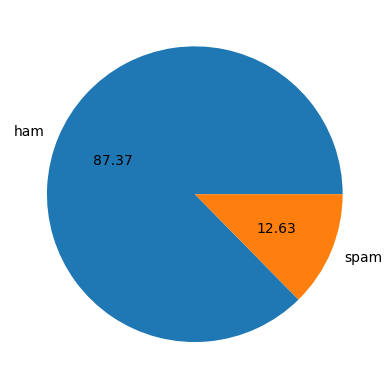

In [32]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels = ['ham','spam'],autopct = "%0.2f")
plt.show()

In [33]:
#Data is imbalanced

In [34]:
import nltk
print(nltk.__version__)

3.9.2


In [35]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KASHIF\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [36]:
df['text'].sample(5)

5514                    Oh... Okie lor...We go on sat... 
1541    Do u konw waht is rael FRIENDSHIP Im gving yuo...
5428                     You didnt complete your gist oh.
3930    Nooooooo I'm gonna be bored to death all day. ...
3422    Had your mobile 10 mths? Update to latest Oran...
Name: text, dtype: object

In [37]:
df['num_characters'] = df['text'].apply(len)

In [38]:
df.sample(5)

,target,text,num_characters
4917,0,Sitting in mu waiting for everyone to get out ...,80
1143,0,And is there a way you can send shade's stuff ...,85
763,0,Nothing but we jus tot u would ask cos u ba gu...,151
3242,0,Pls accept me for one day. Or am begging you c...,63
464,0,Ok i am on the way to railway,29


In [39]:
#number of words in a sentence
df['num_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [40]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [41]:
df['num_sentences'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [42]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [43]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [44]:
df[df['num_characters'] == 910]

,target,text,num_characters,num_words,num_sentences
1084,0,For me the love should start with attraction.i...,910,175,1


In [45]:
#for ham messages
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [46]:
#for spam messages
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [47]:
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

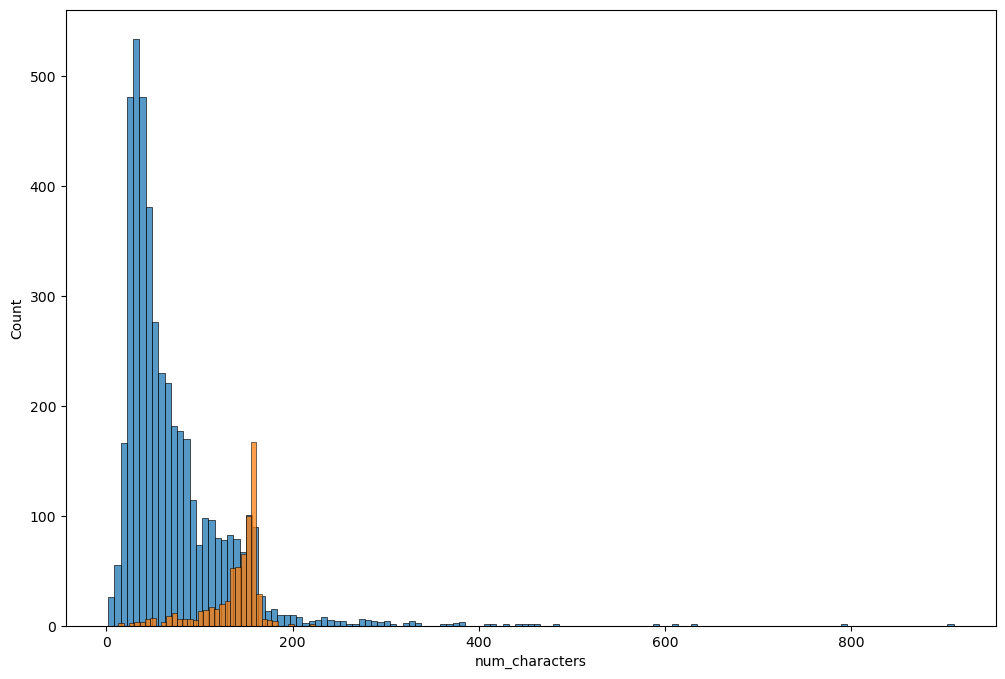

In [48]:
plt.figure(figsize = (12,8))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'])

<Axes: xlabel='num_words', ylabel='Count'>

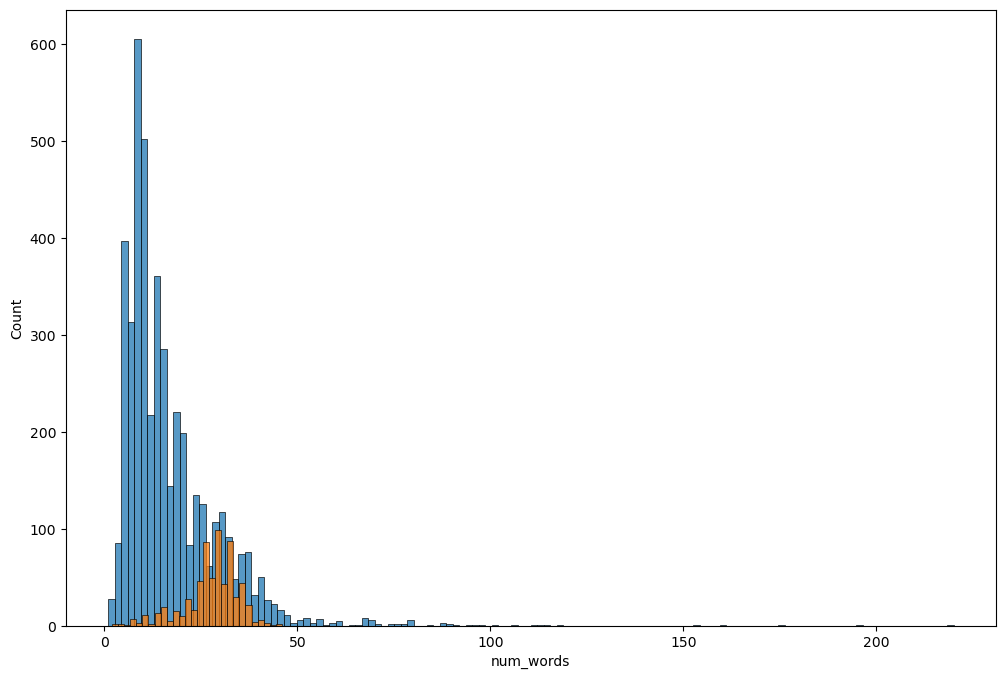

In [49]:
plt.figure(figsize = (12,8))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'])

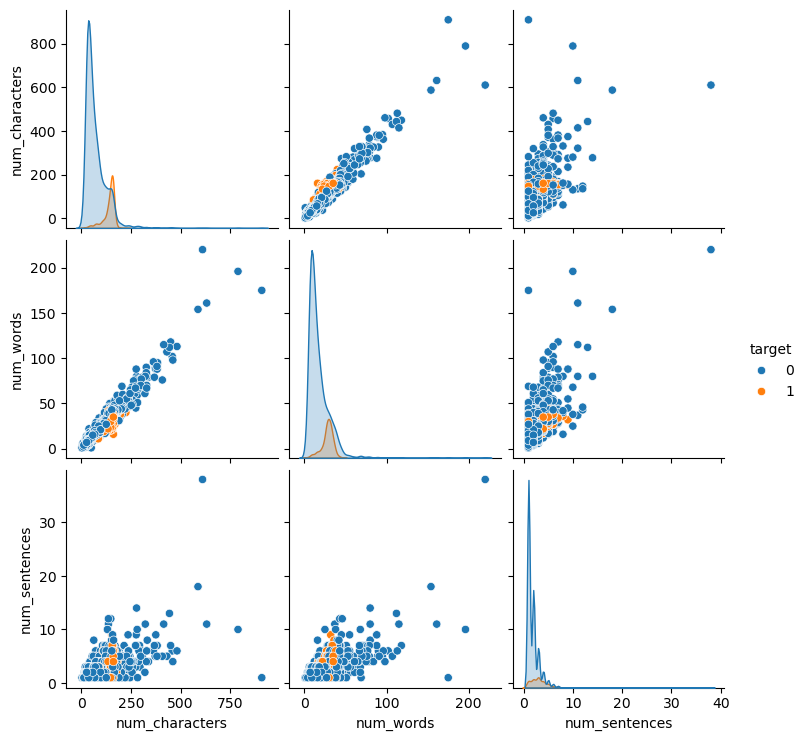

In [50]:
sns.pairplot(df,hue = 'target')

In [51]:
temp = df.drop(columns = 'text')

<Axes: >

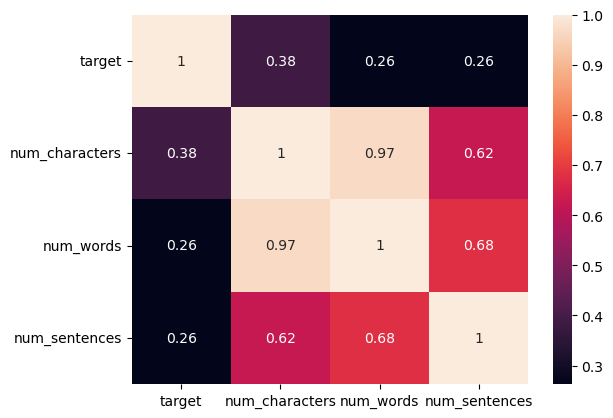

In [52]:
sns.heatmap(temp.corr(),annot = True)

In [53]:
#we will keep the num_charactesr column only as it shows some correlation with target, else rest has strong correlations with each other

# 3.Data Preprocessing
## LowerCase
## Tokenization
## Removing special char
## Removing stop words and punctuation
## Stemming

In [64]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('English') and i not in string.punctuation:
            y.append(i)
    ps = PorterStemmer()
    text = y[:]
    y.clear()
    for i in text:
        z = ps.stem(i)
        y.append(z)
        
    return " ".join(y)

In [65]:
transform_text('a black fox jumped over the rivers to crossing the field , kashif you are a student??')

'black fox jump river cross field kashif student'

In [58]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KASHIF\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [59]:
from nltk.corpus import stopwords
import string

In [63]:
stopwords.words('English')
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [62]:
#for stemming
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loved')

'love'

In [66]:
transform_text(df['text'][3])

'u dun say earli hor u c alreadi say'

In [67]:
df['transformed_text'] = df['text'].apply(transform_text)

In [68]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [69]:
from wordcloud import WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size= 10, background_color='white')

In [70]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep = " "))

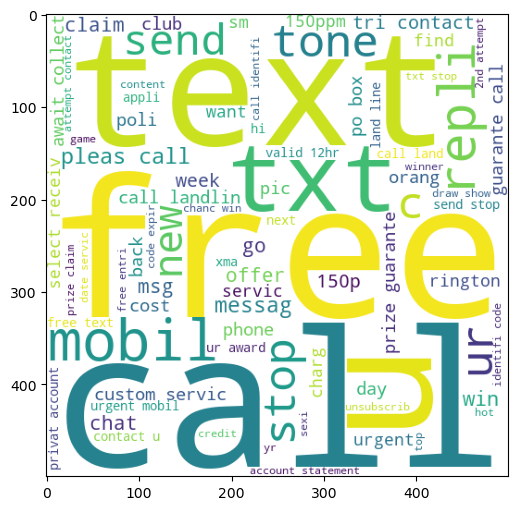

In [71]:
plt.figure(figsize = (15,6))
plt.imshow(spam_wc)

In [72]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep = " "))

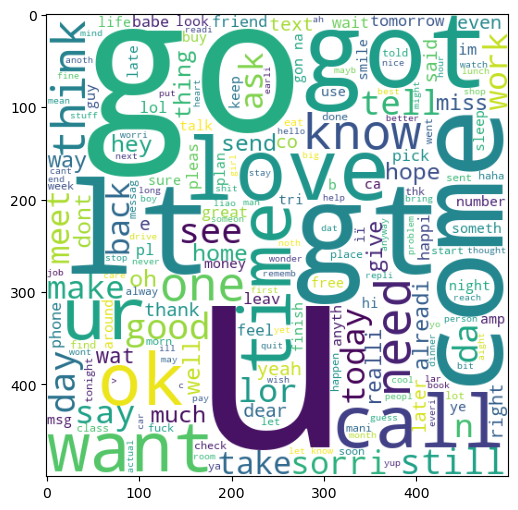

In [73]:
plt.figure(figsize = (15,6))
plt.imshow(ham_wc)

In [74]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [75]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for words in msg.split():
        spam_corpus.append(words)

In [76]:
from collections import Counter

In [77]:
temp = pd.DataFrame(Counter(spam_corpus).most_common(30))
temp

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


C:\Users\KASHIF\AppData\Local\Temp\ipykernel_28132\11070180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=temp, palette='viridis')


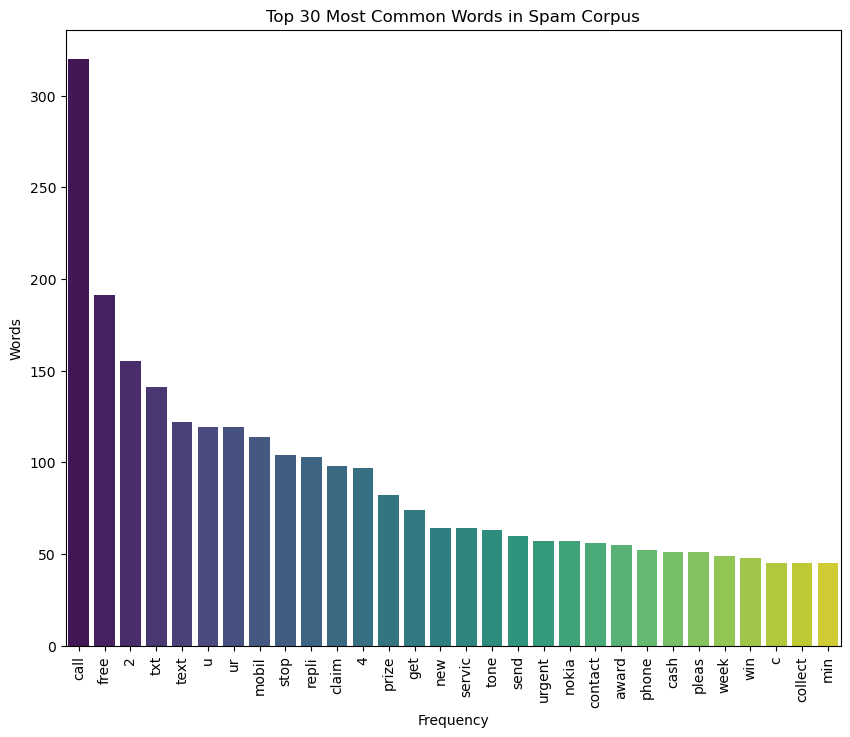

In [78]:
temp.columns = ['Word', 'Count']

# Create a horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Word', y='Count', data=temp, palette='viridis')

# Add titles and labels
plt.xticks(rotation = 'vertical')
plt.title('Top 30 Most Common Words in Spam Corpus')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

In [79]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for words in msg.split():
        ham_corpus.append(words)

In [80]:
temp2 = pd.DataFrame(Counter(ham_corpus).most_common(30))

C:\Users\KASHIF\AppData\Local\Temp\ipykernel_28132\2230610926.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=temp2, palette='viridis')


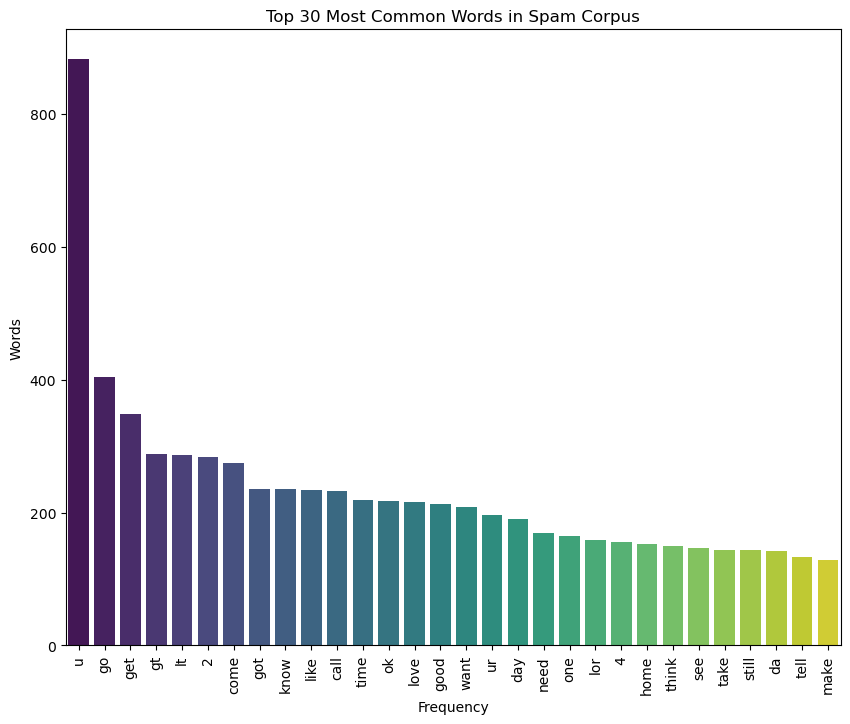

In [81]:
temp2.columns = ['Word', 'Count']

# Create a horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Word', y='Count', data=temp2, palette='viridis')

# Add titles and labels
plt.xticks(rotation = 'vertical')
plt.title('Top 30 Most Common Words in Spam Corpus')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

# Model Building

In [82]:
#text vectorization

In [150]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tf = TfidfVectorizer(max_features = 3000)

In [151]:
X = tf.fit_transform(df['transformed_text']).toarray()

In [113]:
X.shape

(5169, 3000)

In [114]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [115]:
y = df['target'].values

In [116]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
X_train, X_test, y_train, y_test=  train_test_split(X,y,test_size=0.2,random_state=2)

In [118]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [119]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8694390715667312
[[788 108]
 [ 27 111]]
0.5068493150684932


In [146]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [121]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [122]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [123]:

#picking multinomial bayes , as its precision is very good
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC

In [125]:
lr = LogisticRegression(penalty='l1', solver='liblinear')
svc = LinearSVC()
knn = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
rfc = RandomForestClassifier(n_estimators= 50, random_state= 2)
abc = AdaBoostClassifier(n_estimators=50,random_state=2)
bc = BaggingClassifier(n_estimators=50,random_state=2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators= 50,random_state = 2)
xgb = XGBClassifier(n_estimators = 50, random_state = 2)

In [126]:
models = {
    'LR' : lr,
    'SVC' : svc,
    'KNN' : knn,
    'MNB' : mnb,
    'DTC' : dtc,
    'RFC' : rfc,
    'BC' : bc,
    'ETC' : etc,
    'gbdt' : gbdt,
    'xgb' : xgb
}

In [136]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    return accuracy , precision

In [137]:
accuracy_scores = []
precision_scores = []

In [138]:
import time
for name, clf in models.items():
    start = time.time()
    c_accuracy , c_precision = train_classifier(clf,X_train,y_train,X_test,y_test)
    elapsed = time.time() - start
    print("For ", name)
    print("Accuracy - ", c_accuracy)
    print("Precision - ", c_precision)
    print(f"Time     : {elapsed:.2f}s")
    print("-" * 40)
    accuracy_scores.append(c_accuracy)
    precision_scores.append(c_precision)

C:\Users\KASHIF\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\KASHIF\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  LR
Accuracy -  0.9584139264990329
Precision -  0.9702970297029703
Time     : 0.08s
----------------------------------------
For  SVC
Accuracy -  0.9787234042553191
Precision -  0.967741935483871
Time     : 0.06s
----------------------------------------
For  KNN
Accuracy -  0.9052224371373307
Precision -  1.0
Time     : 0.21s
----------------------------------------
For  MNB
Accuracy -  0.9709864603481625
Precision -  1.0
Time     : 0.03s
----------------------------------------
For  DTC
Accuracy -  0.9284332688588007
Precision -  0.82
Time     : 1.13s
----------------------------------------
For  RFC
Accuracy -  0.9758220502901354
Precision -  0.9829059829059829
Time     : 7.58s
----------------------------------------
For  BC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
Time     : 216.99s
----------------------------------------
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
Time     : 27.85s
----------------------------------------
For 

In [140]:
perf_df = pd.DataFrame({'Algorithm' : models.keys(), 'Accuracy' : accuracy_scores, 'Precision' : precision_scores}).sort_values('Precision',ascending = False)

In [141]:
perf_df

,Algorithm,Accuracy,Precision
2,KNN,0.905222,1.000000
3,MNB,0.970986,1.000000
5,RFC,0.975822,0.982906
7,ETC,0.974855,0.974576
0,LR,0.958414,0.970297
1,SVC,0.978723,0.967742
9,xgb,0.970019,0.949580
8,gbdt,0.946809,0.919192
6,BC,0.958414,0.868217
4,DTC,0.928433,0.820000


In [135]:
train_classifier(mnb,X_train,y_train,X_test,y_test)
#model improve
#1. change the max_features parameters of Tfidf

(0.9709864603481625, 1.0)

In [139]:
#can try scaling if it helps (scale X, using minmax scaler or standard scaler) , otherwise skip it

In [142]:
#try using voting ensemble or stacking, to get smooth results if possible , but if it is making it worse you can skip it

In [143]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')
voting.fit(X_train,y_train)
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9816247582205029
Precision 0.9917355371900827


In [144]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()
from sklearn.ensemble import StackingClassifier
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9825918762088974
Precision 0.9545454545454546


In [152]:
import pickle
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(tf, f)

with open('model.pkl', 'wb') as f:
    pickle.dump(mnb, f)